#  Cancer Type Classification via Transcriptomic Biomarkers
## Integrated DESeq2 + Machine Learning Pipeline

**Author:** *Xhovalin Panagiotis Qaazimi*
**Dataset:** TCGA Multi-Cancer RNA-seq
**Goal:** Identify statistically significant gene biomarkers (DEseq2) and use them to classify cancer types with intrerpretable ML models.

---

## Pipeline Overview
```
Raw Counts -> DESeq2 (VST + DE analysis) -> Biomarker Selection (padj<0.05, |LFC| > 1)
           -> Random Forest + XGBoost + SVM -> Cross-Validation -> SHAP Explainability
```

### Selection

1. [Data Loading & QC](#1)
2. [DESeq2 Statistical Analysis](#2)
3. [Biomarker Selection (Volcano + MA Plot)](#3)
4. [Machine learning - Model Comaprison](#4)
5. [SHAP Explainability](#5)
6. [Top Biomarkers - Expression Profiles](#6)

In [1]:
%pip install shap 

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 2.0 MB/s eta 0:00:19
   - -------------------------------------- 1.0/38.1 MB 2.0 MB/s eta 0:00:19
   - -------------------------------------- 1.6/38.1 MB 2.0 MB/s eta 0:00:19
   - -------------------------------------- 1.8/38.1 MB 2.0 MB/s eta 0:00:19
   -- ------------------------------------- 2.4/38.1 MB 2.0 MB/s eta 0:00:19
   -- ------------------------------------- 2.6/38.1 MB 2.0 MB/s eta 0:00:18
   --- ------------------------------------ 3.1/38.1 MB 2.0 MB/s eta 0:00:18
   --- ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# ML 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_auc_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

# XGBoost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' All imports successful')

 All imports successful


<a id='2'></a>

## 2. DESeq2 Statistical Analysis 

DESeq2 uses a **negative binomial model** to detect differentially expressed (DE) genes.
It corrects for library size and gene-wise dispersion - making it the gold standard for RNA-seq analysis.

We apply **Variance Stabilizing Transformation (VST)** to produce normally-distributed counts suitable for ML.

Samples : 801
Genes   : 20531
Classes : 5 → ['PRAD', 'LUAD', 'BRCA', 'KIRC', 'COAD']

Missing values: 0

Class distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78


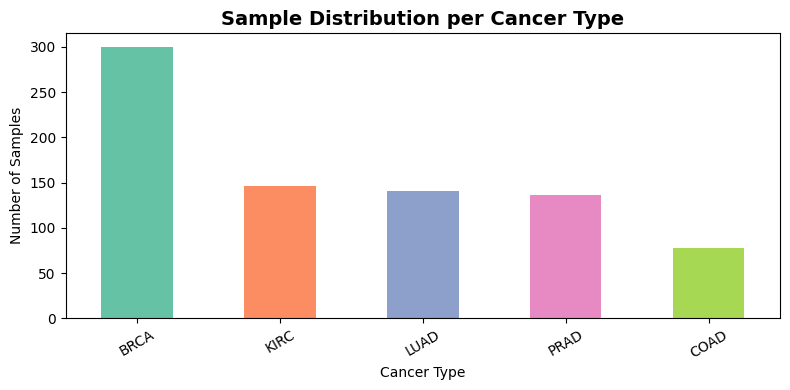

In [6]:
# ─── 1. Data Loading & QC ──────────────────────────────────────────────────
data   = pd.read_csv('data.csv',   index_col=0)
labels = pd.read_csv('labels.csv', index_col=0)

# Ensure orientation: rows = samples, cols = genes
if data.shape[0] != labels.shape[0]:
    data = data.T

# Align index
data   = data.loc[labels.index]
y      = labels['Class']

print(f'Samples : {data.shape[0]}')
print(f'Genes   : {data.shape[1]}')
print(f'Classes : {y.nunique()} → {list(y.unique())}')
print()

# QC — missing values
missing = data.isnull().sum().sum()
print(f'Missing values: {missing}')

# QC — class distribution
class_counts = y.value_counts()
print('\nClass distribution:')
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(class_counts)))
ax.set_title('Sample Distribution per Cancer Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Cancer Type')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


<a id='1'></a>
## Data Loading & Quality Control

We load RNA-seq raw counts and sample metadata. A brief QC step ensures:
- No missing values / zero-count samples
- Class distribution is roughly balanced
- Count matrix orientation is correct (samples × genes)

<a id='2'></a>
##  DESeq2 Statistical Analysis

DESeq2 uses a **negative binomial model** to detect differentially expressed (DE) genes.
It corrects for library size and gene-wise dispersion — making it the gold standard for RNA-seq analysis.

We apply **Variance Stabilizing Transformation (VST)** to produce normally-distributed counts suitable for ML.

In [7]:
# ─── 2. DESeq2 ─────────────────────────────────────────────────────────────
counts_int = data.round().astype(int).clip(lower=0)

# Remove genes with zero variance (speed + stability)
nonzero_genes = counts_int.columns[counts_int.sum(axis=0) > 0]
counts_int = counts_int[nonzero_genes]
print(f'Genes after zero-count filter: {counts_int.shape[1]}')

dds = DeseqDataSet(counts=counts_int, metadata=labels, design_factors='Class')
dds.deseq2()

# VST normalisation for ML
dds.vst(use_design=False)
vst_df = pd.DataFrame(
    dds.layers['vst_counts'],
    index=dds.obs_names,
    columns=dds.var_names
)

print(' DESeq2 complete — VST matrix ready')
print(f'VST matrix shape: {vst_df.shape}')

Genes after zero-count filter: 20247
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.88 seconds.

Fitting dispersions...
... done in 7.54 seconds.

Fitting dispersion trend curve...
... done in 0.33 seconds.

Fitting MAP dispersions...
... done in 14.20 seconds.

Fitting LFCs...
... done in 3.36 seconds.

Calculating cook's distance...
... done in 1.69 seconds.

Replacing 0 outlier genes.

Fitting size factors...


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.83 seconds.

Fitting dispersions...
... done in 6.88 seconds.



 DESeq2 complete — VST matrix ready
VST matrix shape: (801, 20247)


## Biomarker Selection — Volcano & MA Plots

For each pairwise contrast we collect **Differentially Expressed Genes (DEGs)** using:
- Adjusted p-value < 0.05 (Benjamini–Hochberg FDR)
- |log₂ Fold Change| > 1 (at least 2× expression difference)

The union of significant genes across all contrasts forms our **biomarker panel**.

In [9]:
classes = y.unique().tolist()
all_sig_genes = set()
contrast_results = {} # store for volcano plot/MA plots 

for i in range(len(classes)):
     for j in range(i + 1, len(classes)):
        c1, c2 = classes[i], classes[j]
        try:
            stat_res = DeseqStats(dds, contrast=['Class', c1, c2])
            stat_res.summary()
            res_df = stat_res.results_df.dropna()

            # Significant genes: padj < 0.05 AND |LFC| > 1
            sig = res_df[
                (res_df['padj'] < 0.05) &
                (res_df['log2FoldChange'].abs() > 1)
            ]
            all_sig_genes.update(sig.index.tolist())
            contrast_results[f'{c1}_vs_{c2}'] = res_df
            print(f'{c1} vs {c2}: {len(sig)} significant DEGs')
        except Exception as e:
            print(f'  {c1} vs {c2} skipped: {e}')

# Filter to genes present in VST matrix
biomarkers = [g for g in all_sig_genes if g in vst_df.columns]
print(f'\n Total unique biomarkers: {len(biomarkers)}')

Running Wald tests...
... done in 6.34 seconds.



Log2 fold change & Wald test p-value: Class PRAD vs LUAD
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0       0.027346       -0.015566  2.023676 -0.007692  0.993863  0.999842
gene_1       2.994103        0.029467  0.094583  0.311546  0.755386  0.906264
gene_2       3.092531        0.196824  0.090436  2.176396  0.029526  0.075148
gene_3       6.697070        0.002364  0.067418  0.035061  0.972031  0.999842
gene_4       9.764176        0.012437  0.055638  0.223537  0.823117  0.947397
...               ...             ...       ...       ...       ...       ...
gene_20526  11.688901       -0.047732  0.051165 -0.932911  0.350866  0.555867
gene_20527  10.120047        0.055005  0.054616  1.007124  0.313875  0.513455
gene_20528   9.528517        0.053979  0.056313  0.958550  0.337786  0.540943
gene_20529   5.493924        0.141881  0.074179  1.912686  0.055788  0.130387
gene_20530   0.096770       -0.527159  0.931406 -0.565983  0.571406  0.772984

[20247

Running Wald tests...
... done in 1.22 seconds.



Log2 fold change & Wald test p-value: Class PRAD vs BRCA
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_0       0.027346        0.059209  1.741173  0.034005  9.728730e-01   
gene_1       2.994103        0.283919  0.083611  3.395726  6.844687e-04   
gene_2       3.092531        0.492728  0.079736  6.179473  6.431609e-10   
gene_3       6.697070       -0.000736  0.057957 -0.012706  9.898626e-01   
gene_4       9.764176       -0.024041  0.047631 -0.504732  6.137473e-01   
...               ...             ...       ...       ...           ...   
gene_20526  11.688901       -0.041539  0.044164 -0.940567  3.469266e-01   
gene_20527  10.120047        0.031140  0.046693  0.666913  5.048276e-01   
gene_20528   9.528517        0.000329  0.047992  0.006849  9.945351e-01   
gene_20529   5.493924       -0.080151  0.061755 -1.297890  1.943252e-01   
gene_20530   0.096770       -0.104295  0.810188 -0.128730  8.975715e-01   

                    padj  
gene_0      9.9

Running Wald tests...
... done in 1.30 seconds.



...

Running Wald tests...
... done in 1.36 seconds.



Log2 fold change & Wald test p-value: Class BRCA vs COAD
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_0       0.027346       -0.095511  2.140011 -0.044631  9.644012e-01   
gene_1       2.994103       -0.311044  0.101266 -3.071570  2.129365e-03   
gene_2       3.092531       -0.208488  0.103774 -2.009061  4.453064e-02   
gene_3       6.697070       -0.245530  0.066892 -3.670574  2.420061e-04   
gene_4       9.764176        0.001963  0.058428  0.033597  9.731982e-01   
...               ...             ...       ...       ...           ...   
gene_20526  11.688901       -0.077824  0.052791 -1.474184  1.404321e-01   
gene_20527  10.120047       -0.033462  0.057473 -0.582234  5.604088e-01   
gene_20528   9.528517        0.042205  0.059871  0.704918  4.808611e-01   
gene_20529   5.493924        0.778609  0.093244  8.350262  6.811160e-17   
gene_20530   0.096770        0.031001  0.993833  0.031193  9.751156e-01   

                    padj  
gene_0      9.9

Running Wald tests...


Log2 fold change & Wald test p-value: Class KIRC vs COAD
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_0       0.027346        0.020082  2.360637  0.008507  9.932124e-01   
gene_1       2.994103       -0.542656  0.117359 -4.623892  3.766062e-06   
gene_2       3.092531       -0.418975  0.119110 -3.517538  4.355701e-04   
gene_3       6.697070       -0.309562  0.075392 -4.106043  4.024954e-05   
gene_4       9.764176       -0.076851  0.065093 -1.180638  2.377467e-01   
...               ...             ...       ...       ...           ...   
gene_20526  11.688901       -0.061702  0.058367 -1.057135  2.904501e-01   
gene_20527  10.120047       -0.017101  0.063403 -0.269714  7.873807e-01   
gene_20528   9.528517       -0.002318  0.066285 -0.034974  9.721008e-01   
gene_20529   5.493924        0.505289  0.101945  4.956496  7.177577e-07   
gene_20530   0.096770        0.240008  1.092209  0.219745  8.260694e-01   

                padj  
gene_0      0.99996

... done in 1.21 seconds.



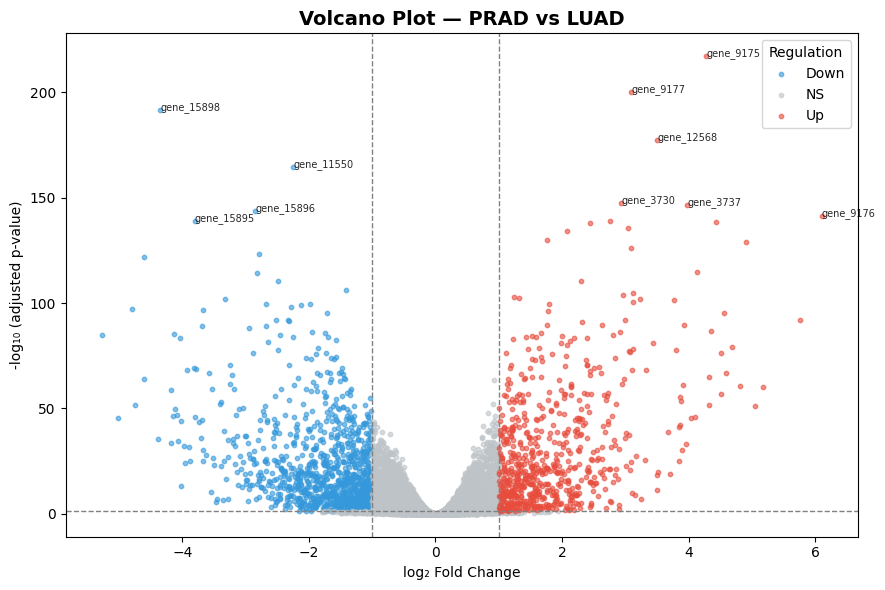

DE
NS      18526
Down     1047
Up        674


In [11]:
# ─── Volcano Plot (first contrast) ─────────────────────────────────────────
if contrast_results:
    key   = list(contrast_results.keys())[0]
    res   = contrast_results[key].copy()
    res['-log10(padj)'] = -np.log10(res['padj'].clip(lower=1e-300))

    def classify(row):
        if row['padj'] < 0.05 and row['log2FoldChange'] >  1: return 'Up'
        if row['padj'] < 0.05 and row['log2FoldChange'] < -1: return 'Down'
        return 'NS'

    res['DE'] = res.apply(classify, axis=1)
    palette   = {'Up': '#e74c3c', 'Down': '#3498db', 'NS': '#bdc3c7'}

    fig, ax = plt.subplots(figsize=(9, 6))
    for label, grp in res.groupby('DE'):
        ax.scatter(grp['log2FoldChange'], grp['-log10(padj)'],
                   c=palette[label], s=10, alpha=0.6, label=label)

    ax.axhline(-np.log10(0.05), color='grey', linestyle='--', lw=1)
    ax.axvline( 1,  color='grey', linestyle='--', lw=1)
    ax.axvline(-1,  color='grey', linestyle='--', lw=1)

    # Label top 10 genes by significance
    top10 = res[res['DE'] != 'NS'].nsmallest(10, 'padj')
    for gene, row in top10.iterrows():
        ax.annotate(gene, (row['log2FoldChange'], row['-log10(padj)']),
                    fontsize=7, alpha=0.85)

    ax.set_title(f'Volcano Plot — {key.replace("_", " ")}', fontsize=14, fontweight='bold')
    ax.set_xlabel('log₂ Fold Change')
    ax.set_ylabel('-log₁₀ (adjusted p-value)')
    ax.legend(title='Regulation')
    plt.tight_layout()
    plt.show()
    counts = res['DE'].value_counts()
    print(counts.to_string())

### MA Plot Visualization

**Libraries used:** `matplotlib.pyplot` (for plotting), `pandas` (for DataFrame operations).

This section generates an **MA Plot** to visualize the differential gene expression analysis results:
* **Filtering:** It identifies significant Differentially Expressed Genes (DEGs) by applying a threshold: adjusted p-value (`padj`) < 0.05 and absolute `log2FoldChange` > 1.
* **Plotting:** It scatters the mean expression (`baseMean`) on a logarithmic X-axis against the fold change (`log2FoldChange`) on the Y-axis.
* **Styling & Exporting:** Significant genes are highlighted in red, while non-significant ones remain grey. Reference lines are drawn at 0, 1, and -1 log₂ fold changes. The final plot is displayed and saved as a PNG image in the `results/figures/` directory.

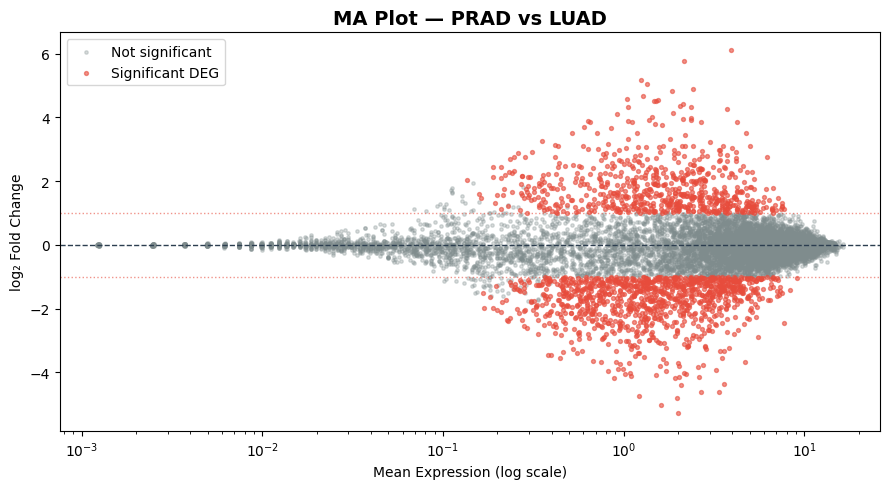

In [13]:
# ─── MA Plot ───────────────────────────────────────────────────────────────
if contrast_results:
    key = list(contrast_results.keys())[0]
    res = contrast_results[key].copy()
    sig_mask = (res['padj'] < 0.05) & (res['log2FoldChange'].abs() > 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(res.loc[~sig_mask, 'baseMean'], res.loc[~sig_mask, 'log2FoldChange'],
               s=6, alpha=0.3, color='#7f8c8d', label='Not significant')
    ax.scatter(res.loc[sig_mask,  'baseMean'], res.loc[sig_mask,  'log2FoldChange'],
               s=8, alpha=0.6, color='#e74c3c', label='Significant DEG')
    ax.axhline(0,  color='#2c3e50', linestyle='--', lw=1)
    ax.axhline( 1, color='#e74c3c', linestyle=':', lw=1, alpha=0.6)
    ax.axhline(-1, color='#e74c3c', linestyle=':', lw=1, alpha=0.6)
    ax.set_xscale('log')
    ax.set_title(f'MA Plot — {key.replace("_", " ")}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mean Expression (log scale)')
    ax.set_ylabel('log₂ Fold Change')
    ax.legend()
    plt.tight_layout()
    plt.show()


<a id='4'></a>
## 4. Machine Learning — Model Comparison

We train three classifiers on the DESeq2-selected biomarker features:
| Model | Strength |
|---|---|
| Random Forest | Robust, handles high-dim data, interpretable via feature importance |
| XGBoost | State-of-the-art gradient boosting |
| SVM (RBF) | Effective in high-dimensional spaces |

All models are evaluated with **5-fold Stratified Cross-Validation** to avoid overfitting.

Using 4498 DESeq2-selected biomarkers

=== 5-Fold Cross-Validation Results ===
Random Forest        Accuracy: 0.9969 ± 0.0038
SVM (RBF)            Accuracy: 0.9953 ± 0.0038
XGBoost              Accuracy: 0.9938 ± 0.0058


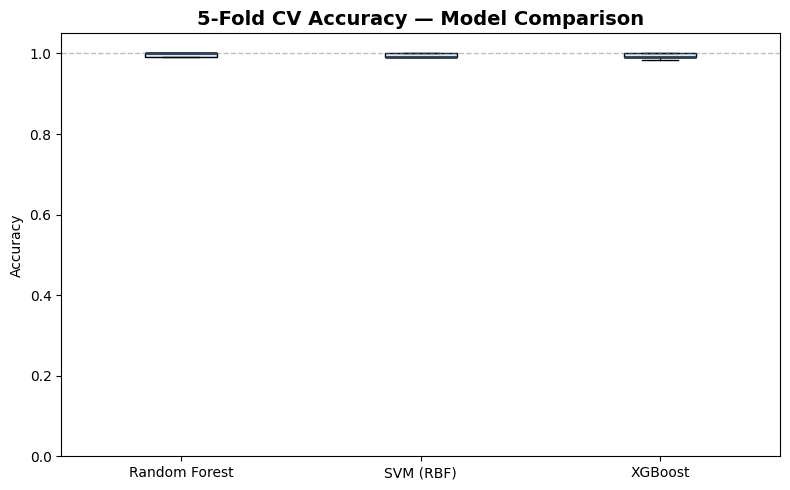

In [19]:
# ─── 4. Model Training & Cross-Validation ──────────────────────────────────
# Use biomarkers if found, else fall back to top-500 by variance
if len(biomarkers) >= 10:
    features = biomarkers
    print(f'Using {len(features)} DESeq2-selected biomarkers')
else:
    features = vst_df.var().nlargest(500).index.tolist()
    print(f'Fallback: using top-500 high-variance genes')

X = vst_df[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Define models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('svc',    SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE))
    ]),
}
if XGB_AVAILABLE:
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    y_train_enc = le.transform(y_train)
    y_test_enc  = le.transform(y_test)
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

# 5-Fold CV comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('\n=== 5-Fold Cross-Validation Results ===')
for name, model in models.items():
    y_input = y_train_enc if (name == 'XGBoost' and XGB_AVAILABLE) else y_train
    scores = cross_val_score(model, X_train, y_input, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<20} Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# Plot CV comparison
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [cv_results[m] for m in cv_results],
    labels=list(cv_results.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#d6eaf8'),
    medianprops=dict(color='#2c3e50', lw=2)
)
ax.set_title('5-Fold CV Accuracy — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color='grey', linestyle='--', lw=1, alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
# ─── Best Model — Full Evaluation ──────────────────────────────────────────
best_name = max(cv_results, key=lambda m: cv_results[m].mean())
best_model = models[best_name]
print(f'Best model: {best_name}')

y_tr = y_train_enc if (best_name == 'XGBoost' and XGB_AVAILABLE) else y_train
y_te = y_test_enc  if (best_name == 'XGBoost' and XGB_AVAILABLE) else y_test

# 1. FIT THE MODEL FIRST
best_model.fit(X_train, y_tr)

# 2. NOW GET THE CLASSES
# (If it's XGBoost, use the LabelEncoder; otherwise, pull from the fitted model)
if best_name == 'XGBoost' and XGB_AVAILABLE:
    class_labels = le.classes_
else:
    # If it's a Pipeline (like your SVM), you need to access the classifier inside the pipe
    if isinstance(best_model, Pipeline):
        class_labels = best_model.named_steps['svc'].classes_
    else:
        class_labels = best_model.classes_

y_pred = best_model.predict(X_test)

Best model: Random Forest



Test Accuracy : 0.9876

Classification Report:
              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       0.99      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161



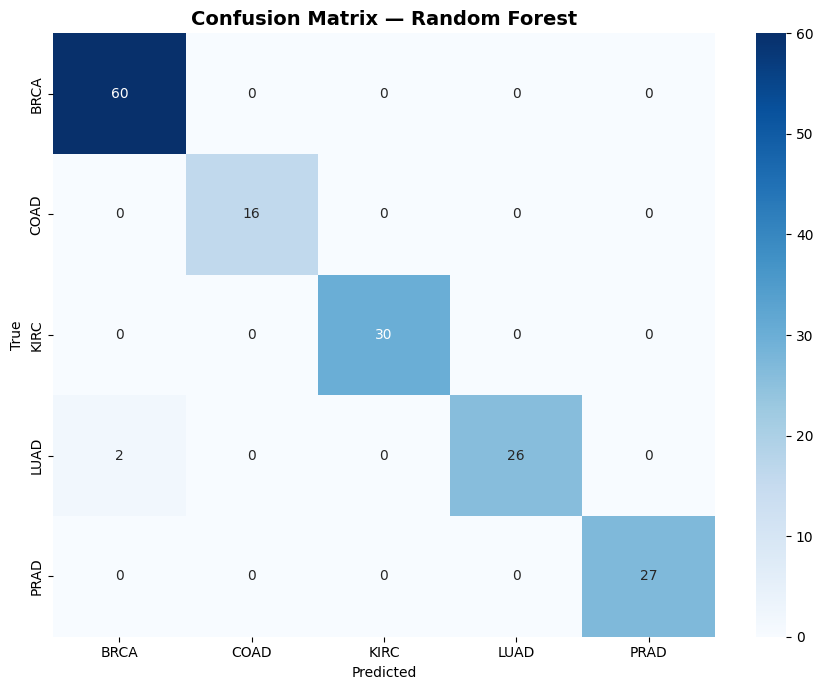

In [22]:

print(f'\nTest Accuracy : {accuracy_score(y_te, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_te, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. SHAP Explainability

**SHAP (SHapley Additive exPlanations)** provides gene-level contribution scores for each prediction.
This is critical in biomedical ML — it lets clinicians understand *why* the model classified a sample as a specific cancer type.

A high SHAP value for a gene means it strongly pushed the prediction toward a class.


=== SHAP Explainability (Random Forest) ===
Top 15 genes by mean |SHAP| value:
gene_7964     0.009035
gene_18746    0.006015
gene_11910    0.004920
gene_7896     0.004813
gene_5578     0.004706
gene_15589    0.004209
gene_17801    0.004156
gene_15898    0.004111
gene_9652     0.003775
gene_6611     0.003677
gene_203      0.003489
gene_18135    0.003314
gene_15895    0.003076
gene_8349     0.003066
gene_15899    0.002945


<Figure size 1000x600 with 0 Axes>

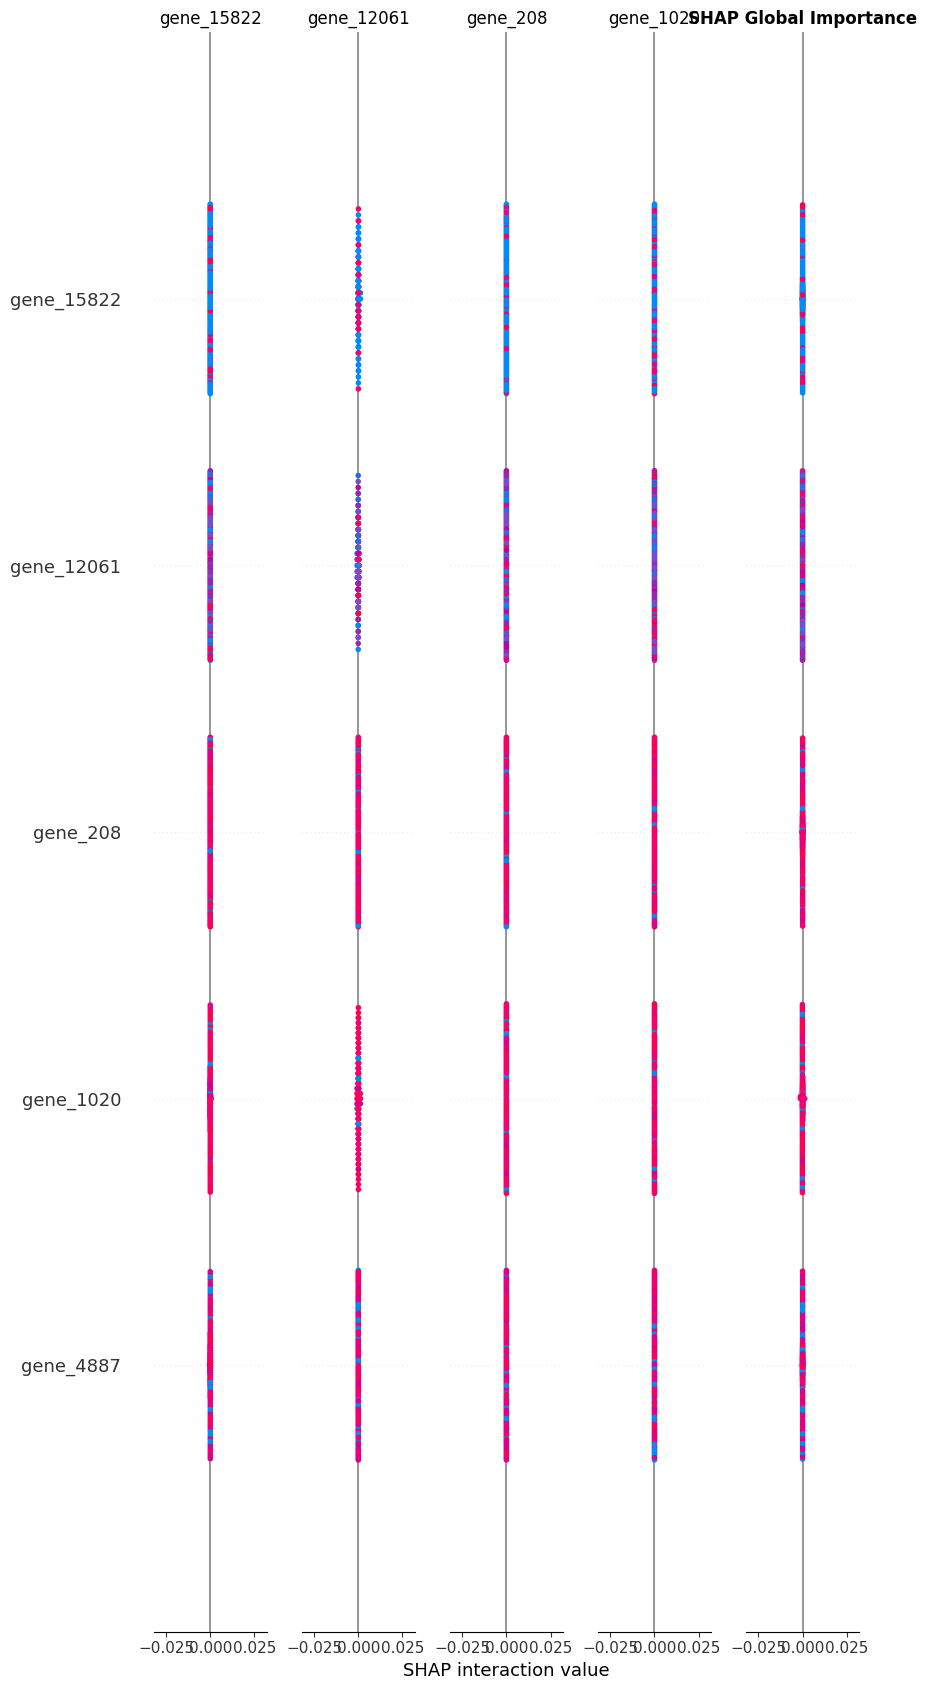

In [25]:
if SHAP_AVAILABLE:
    print('\n=== SHAP Explainability (Random Forest) ===')
    rf_model = models['Random Forest']
    
    if not hasattr(rf_model, 'estimators_'):
        rf_model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test)

    # Διόρθωση ValueError: Υπολογισμός μέσης επίδρασης ανά feature
    if isinstance(shap_values, list):
        # Multi-class: list of (n_samples, n_features)
        mean_abs_per_class = [np.abs(sv).mean(axis=0) for sv in shap_values]
        final_importance = np.mean(mean_abs_per_class, axis=0)
    else:
        # Single array case
        if shap_values.ndim == 3: # (samples, features, classes)
            final_importance = np.abs(shap_values).mean(axis=(0, 2))
        else:
            final_importance = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.Series(
        final_importance, 
        index=X_test.columns
    ).sort_values(ascending=False)

    print('Top 15 genes by mean |SHAP| value:')
    print(shap_importance.head(15).to_string())

    # SHAP summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, 
        X_test, 
        max_display=20, 
        show=False
    )
    plt.title('SHAP Global Importance', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\nSHAP not available. Skipping explainability.')

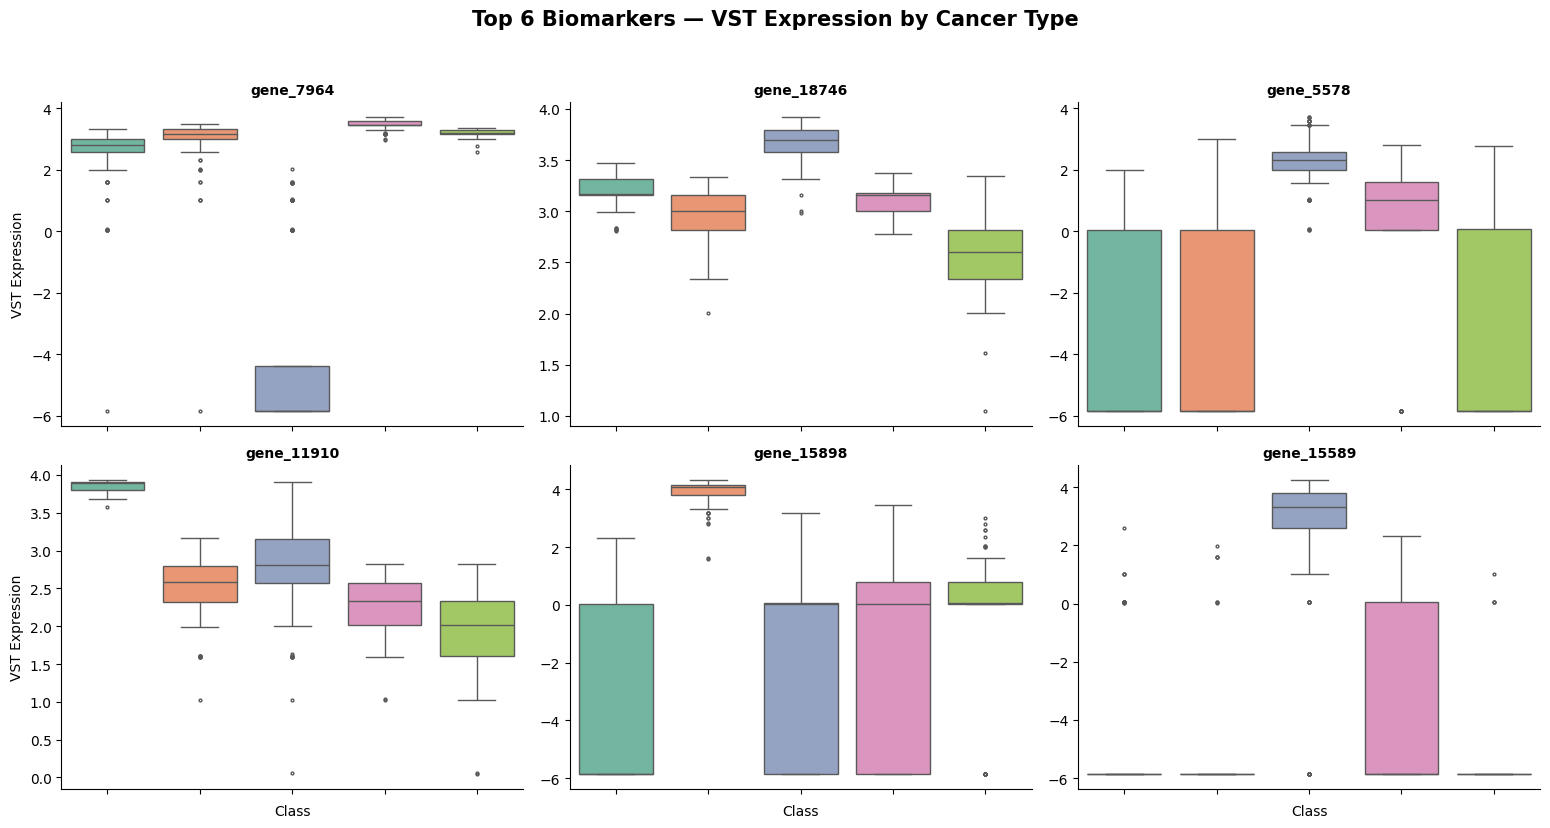

In [27]:
# ─── 6. Biomarker Expression Boxplots ──────────────────────────────────────
rf_for_importance = models['Random Forest']
if not hasattr(rf_for_importance, 'estimators_'):
    rf_for_importance.fit(X_train, y_train)

importances = pd.Series(
    rf_for_importance.feature_importances_,
    index=features
)
top6 = importances.nlargest(6).index.tolist()

plot_df = vst_df[top6].copy()
plot_df['Class'] = labels['Class']
plot_melted = plot_df.melt(id_vars='Class', var_name='Gene', value_name='VST Expression')

palette = sns.color_palette('Set2', y.nunique())
g = sns.FacetGrid(
    plot_melted, col='Gene', col_wrap=3,
    sharey=False, height=4, aspect=1.3
)
g.map_dataframe(sns.boxplot, x='Class', y='VST Expression',
                palette='Set2', flierprops={'markersize': 2})
g.set_titles(col_template='{col_name}', fontweight='bold')
g.set_xticklabels(rotation=30)
g.fig.suptitle('Top 6 Biomarkers — VST Expression by Cancer Type',
               y=1.03, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Summary

| Step | Result |
|---|---|
| DESeq2 biomarkers identified | See output above |
| Best model (5-fold CV) | See Section 4 |
| Test accuracy | See Section 4 |
| Top SHAP biomarker | See Section 5 |

### Key Findings
- DESeq2 with `padj < 0.05` and `|LFC| > 1` provides a principled, reproducible biomarker panel
- VST-normalised counts outperform raw log₂ for ML input
- Cross-validation prevents overfit reporting of accuracy
- SHAP values provide biological interpretability beyond black-box accuracy


